# Follow-along — Recitation 1: Python and NumPy

**CPSY 1291 · Computational Cognitive Science · Brown University**

This notebook is the companion to **Recitation 1**. It is **optional and
ungraded**, like the recitation itself. Open it in Colab and bring it to the
session: the parts marked **RUN WITH ME (in recitation)** are the ones we do
together, and the parts marked **AT HOME** are extra practice that 80 minutes
cannot fit. If you missed the session, nothing is lost — the notebook stands
on its own; work top to bottom.

**How the exercises work** (same rules as the warmup notebook): each exercise
cell comes pre-filled with one possible answer, so the notebook runs cleanly
end to end. You will learn far more if you **delete the sample answer and
write your own**, then run the locked check cell below it — it will either
congratulate you or tell you what to fix. You cannot break anything. If a
check fails, edit your answer and run both cells again.

## 1. The data for today — RUN WITH ME (in recitation)

Everything in this notebook happens to one small dataset with a story. One
afternoon, **12 stimuli** — four birds, four mammals, and four insects, shown
in interleaved order — were presented while **8 units** were recorded. Two
electrodes died before the session started, and one amplifier had its gain set
10× too high. None of this is exotic; it is a miniature of what Assignment 1's
arrays look like, at a size where you can print everything.

The array follows the course convention: **stimuli × features** — one row per
stimulus, one column per recorded unit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1291)     # seeded: everyone sees the same numbers

n_stimuli, n_units = 12, 8
taxon = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2])   # presentation order
taxon_names = ["bird", "mammal", "insect"]

centers = rng.uniform(2.0, 8.0, size=(3, n_units))  # each group's typical rates
# (centers[taxon] is *fancy indexing* — section 7 explains it. For now:
#  row taxon[i] of centers becomes stimulus i's baseline.)
R = centers[taxon] + rng.normal(0.0, 0.8, size=(n_stimuli, n_units))
R = np.clip(R, 0.0, None)     # firing rates cannot be negative
R[:, 2] = 0.0                 # unit 2's electrode died before the session
R[:, 5] = 0.0                 # so did unit 5's
R[:, 7] *= 10.0               # unit 7's amplifier gain was set 10x too high

print("R.shape:", R.shape, "  R.dtype:", R.dtype)
print("min:", R.min().round(2), "  max:", R.max().round(2))
print("taxon:", taxon)

R.shape: (12, 8)   R.dtype: float64
min: 0.0   max: 58.94
taxon: [0 1 2 0 1 2 0 1 2 0 1 2]


**Look before you compute.** The habit the assignments reward most: before
trusting any number computed from an array, look at the array. Two columns
below are flat black and one is far brighter than everything else — the
picture already tells you most of what is wrong with this dataset.

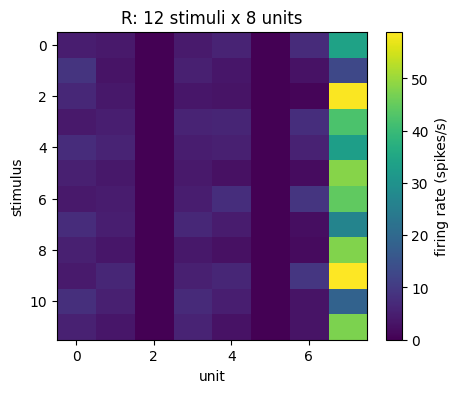

In [2]:
plt.figure(figsize=(5, 4))
plt.imshow(R, aspect="auto")
plt.colorbar(label="firing rate (spikes/s)")
plt.xlabel("unit")
plt.ylabel("stimulus")
plt.title("R: 12 stimuli x 8 units")
plt.show()

## 2. `axis=` and `keepdims` — RUN WITH ME (in recitation)

The rule that ends the guessing: **the axis you name is the axis that
disappears.** `R` is `(12, 8)`, so `axis=0` collapses the 12 stimuli and
leaves one number per unit; `axis=1` collapses the 8 units and leaves one
number per stimulus. `keepdims=True` keeps the collapsed axis as length 1
instead of removing it — it will earn its keep in the next section.

In [3]:
print("R.mean(axis=0).shape:", R.mean(axis=0).shape, "  <- one number per unit")
print("R.mean(axis=1).shape:", R.mean(axis=1).shape, "  <- one number per stimulus")
print("R.mean(axis=1, keepdims=True).shape:", R.mean(axis=1, keepdims=True).shape)
print()
print("mean rate per unit:", R.mean(axis=0).round(1))

R.mean(axis=0).shape: (8,)   <- one number per unit
R.mean(axis=1).shape: (12,)   <- one number per stimulus
R.mean(axis=1, keepdims=True).shape: (12, 1)

mean rate per unit: [ 5.9  4.5  0.   5.1  4.6  0.   4.5 39.4]


Read that last line against the story: two entries are exactly 0 (the dead
electrodes) and one is enormous (the loud amplifier). The mean found them;
the **variance across stimuli** finds them even more sharply, and that is
your exercise.

### Exercise 2.1 — one number per stimulus, one per unit — RUN WITH ME (in recitation)

Compute two arrays from `R`:

- `rate_per_stimulus` — each stimulus's mean rate over the 8 units; shape `(12,)`
- `var_per_unit` — each unit's variance across the 12 stimuli; shape `(8,)`.
  This is the **dead-unit detector**: a unit that never changes has variance 0.

In [4]:
rate_per_stimulus = R.mean(axis=1)  # one possible answer — delete and write your own
var_per_unit = R.var(axis=0)        # one possible answer — delete and write your own

In [5]:
# Check cell — run me, do not edit me.
assert rate_per_stimulus.shape == (12,), (
    f"rate_per_stimulus should have shape (12,), one number per stimulus; yours is "
    f"{rate_per_stimulus.shape}. The axis you name disappears — to keep 12 stimuli, "
    "collapse the units axis (axis=1).")
assert var_per_unit.shape == (8,), (
    f"var_per_unit should have shape (8,), one number per unit; yours is "
    f"{var_per_unit.shape}. To keep 8 units, collapse the stimulus axis (axis=0).")
assert var_per_unit[2] == 0 and var_per_unit[5] == 0, (
    "Units 2 and 5 are dead, so their variance across stimuli must be exactly 0. "
    "If yours is not, you collapsed the wrong axis or computed something other "
    "than the variance (R.var).")
assert np.allclose(rate_per_stimulus, R.mean(axis=1)), (
    "rate_per_stimulus has the right shape but the wrong values — it should be the "
    "MEAN over units, not a sum or variance.")
print("Exercise 2.1 passed. The dead units confess in axis=0's variance,")
print("and the loud one screams there too:", var_per_unit.round(1))

Exercise 2.1 passed. The dead units confess in axis=0's variance,
and the loud one screams there too: [  2.7   0.9   0.    1.1   2.5   0.    8.6 197.7]


## 3. Broadcasting, and the error it throws — RUN WITH ME (in recitation)

When shapes differ, numpy stretches size-1 dimensions to match. The rule:
**compare shapes from the right; each pair must be equal, or one must be 1.**
Below, the first two lines work and the third refuses — read the message
carefully, because you will meet it again in Assignment 1.

In [6]:
col_centered = R - R.mean(axis=0)                  # (12,8) - (8,)   -> works
row_centered = R - R.mean(axis=1, keepdims=True)   # (12,8) - (12,1) -> works

try:
    R - R.mean(axis=1)                             # (12,8) - (12,)  -> refuses
except ValueError as e:
    print("ValueError:", e)

ValueError: operands could not be broadcast together with shapes (12,8) (12,) 


Aligned from the right, `(12,)` lines up against the 8, not the 12 — neither
is 1, so numpy refuses. `keepdims=True` makes the mean `(12, 1)`, which
stretches. That is all `keepdims` is for.

The two working lines answer different questions about this data.
Column-centering removes each **unit's** baseline — after it, the loud unit's
mean is 0 like everyone else's (though its fluctuations are still 10× too
big; taming those is z-scoring, which part 3 of A1 will ask about).
Row-centering removes each **stimulus's** overall level — and in A1's 1b that
row-centering is exactly what turns cosine distance into correlation distance.

### Exercise 3.1 — center each stimulus on its own mean — RUN WITH ME (in recitation)

Compute `R_rowcentered`: subtract from each row of `R` that row's own mean.
The result must have the same shape as `R`, and every row must now average
to zero.

In [7]:
R_rowcentered = R - R.mean(axis=1, keepdims=True)  # one possible answer — delete and write your own

In [8]:
# Check cell — run me, do not edit me.
assert R_rowcentered.shape == R.shape, (
    f"R_rowcentered should keep R's shape (12, 8); yours is {R_rowcentered.shape}. "
    "If you got a ValueError instead, that is the broadcasting error from above — "
    "keepdims=True is the fix.")
assert np.allclose(R_rowcentered.mean(axis=1), 0), (
    "Each ROW should now average to zero, and yours do not. Did you subtract the "
    "column means (axis=0) instead of each row's own mean (axis=1)?")
print("Exercise 3.1 passed. keepdims is what keeps the subtraction lined up.")

Exercise 3.1 passed. keepdims is what keeps the subtraction lined up.


## 4. Three symbols: `.T`, `@`, `[:, None]` — RUN WITH ME (in recitation)

Three vocabulary items the next section is unreadable without. `.T` flips
rows and columns. `A @ B` is **matrix multiplication** — shapes must chain,
`(n, p) @ (p, m) -> (n, m)` — and it is *not* the decorator `@` that sits
above function definitions in Python tutorials. `v[:, None]` inserts a
size-1 axis by hand: the `keepdims` idea, written yourself.

In [9]:
print("R.shape:", R.shape, "   R.T.shape:", R.T.shape)

G = R @ R.T
print("(R @ R.T).shape:", G.shape, "  <- every stimulus dotted with every stimulus")

v = R.mean(axis=1)
print("v:", v.shape, "   v[:, None]:", v[:, None].shape, "   v[None, :]:", v[None, :].shape)
print("keepdims, written by hand:",
      np.allclose(R.mean(axis=1, keepdims=True), v[:, None]))

R.shape: (12, 8)    R.T.shape: (8, 12)
(R @ R.T).shape: (12, 12)   <- every stimulus dotted with every stimulus
v: (12,)    v[:, None]: (12, 1)    v[None, :]: (1, 12)
keepdims, written by hand: True


## 5. The 1b idiom, decoded — RUN WITH ME (in recitation)

Assignment 1's 1b *gives* you the Euclidean shape-move as a hint; your job is
to read it. It is high-school algebra done to whole rows at once:
$\lVert x_i - x_j \rVert^2 = \lVert x_i \rVert^2 + \lVert x_j \rVert^2 - 2\, x_i \cdot x_j$
— the familiar $(a-b)^2 = a^2 + b^2 - 2ab$, for all pairs simultaneously.

- `sq[:, None] + sq[None, :]` — a `(12,1) + (1,12)` broadcast: **every pairwise sum**
- `R @ R.T` — every pairwise dot product, in one multiplication

In [10]:
sq = (R ** 2).sum(axis=1)                        # (12,)  each row's squared length
D2 = sq[:, None] + sq[None, :] - 2 * (R @ R.T)   # (12,12) all squared distances

print("D2.shape:", D2.shape)
print("smallest diagonal entry:", np.diag(D2).min())

D = np.sqrt(np.maximum(D2, 0))                   # the clip is NOT paranoia — see below
print("D[0, :4]:", D[0, :4].round(2))

D2.shape: (12, 12)
smallest diagonal entry: -9.094947017729282e-13
D[0, :4]: [ 0.   22.04 25.8   8.56]


Look at that diagonal entry: the true value is 0 (each stimulus is at
distance 0 from itself), but floating point leaves debris around $10^{-13}$ —
and `sqrt` of a tiny *negative* number is `nan`, which then poisons everything
downstream. `np.maximum(D2, 0)` is the standard clip; you will want it in 1b.

Never trust an idiom you have not tested against something dumb and obviously
correct. Here is the same matrix from a plain double loop:

In [11]:
D_loop = np.zeros((n_stimuli, n_stimuli))
for i in range(n_stimuli):
    for j in range(n_stimuli):
        D_loop[i, j] = np.sqrt(((R[i] - R[j]) ** 2).sum())

print("largest disagreement:", np.abs(D - D_loop).max())
print("idiom agrees with the loop:", np.allclose(D, D_loop, atol=1e-5))

largest disagreement: 9.5367431640625e-07
idiom agrees with the loop: True


Note the tolerance. The two computations disagree by about $10^{-6}$ — the
same floating-point debris we just clipped, surviving the square root where
the true distance is 0. For floats, "agrees" always means *within tolerance*
(A1's 1d checks your functions against SciPy the same way), never `==` —
more on that in section 8's gallery.

### Exercise 5.1 — cosine distance in two lines — AT HOME

The recitation deck shows the two-line cosine skeleton: divide each row by
its length (`np.linalg.norm(..., axis=1, keepdims=True)` — `keepdims` doing
real work again), then `1 - n_hat @ n_hat.T`. Build `C`, the `(12, 12)`
cosine-distance matrix of `R`.

In [12]:
n_hat = R / np.linalg.norm(R, axis=1, keepdims=True)  # one possible answer — delete and write your own
C = 1 - n_hat @ n_hat.T                               # one possible answer — delete and write your own

In [13]:
# Check cell — run me, do not edit me.
assert C.shape == (12, 12), (
    f"C should be (12, 12); yours is {C.shape}. If you got (8, 8), you normalized "
    "columns instead of rows — the norm needs axis=1.")
assert np.allclose(np.diag(C), 0, atol=1e-9), (
    "Every stimulus has cosine distance 0 to itself, so the diagonal should be "
    "(numerically) zero. Check that you subtracted from 1, not the other way around.")
assert np.allclose(C, C.T), (
    "A distance matrix must be symmetric, and yours is not — something other than "
    "n_hat @ n_hat.T happened in line two.")
assert abs(C[0, 1] - 0.1126) < 1e-3, (
    "The shape and diagonal are right but the values are off — most likely the rows "
    "were not divided by their norms (keepdims=True matters in line one).")
print("Exercise 5.1 passed. Correlation distance is these same two lines after")
print("row-centering (section 3) — one line different, as 1b says.")

Exercise 5.1 passed. Correlation distance is these same two lines after
row-centering (section 3) — one line different, as 1b says.


## 6. Boolean masks, `&` `|` `~`, and the other error — RUN WITH ME (in recitation)

A comparison on an array gives an array of `True`/`False` — one answer per
element. Masks select rows, count (`True` counts as 1), and — the quiet star —
**the mean of a mask is a fraction**.

In [14]:
mask = (taxon == 0)                     # one True/False per stimulus
print("mask:      ", mask)
print("how many birds:", mask.sum(), "   what fraction:", round(mask.mean(), 3))
print("R[mask].shape:", R[mask].shape, "  <- just the bird rows")
print()
print("values and counts:", np.unique(taxon, return_counts=True))
print("bird or insect:   ", ((taxon == 0) | (taxon == 2)))   # parentheses required
print("same, via isin:   ", np.isin(taxon, [0, 2]))

mask:       [ True False False  True False False  True False False  True False False]
how many birds: 4    what fraction: 0.333
R[mask].shape: (4, 8)   <- just the bird rows

values and counts: (array([0, 1, 2]), array([4, 4, 4]))
bird or insect:    [ True False  True  True False  True  True False  True  True False  True]
same, via isin:    [ True False  True  True False  True  True False  True  True False  True]


Two things to watch. First: element-wise logic on arrays is `&` `|` `~`,
**always with parentheses** — `|` binds tighter than `==`. Write Python's
`and`/`or` between arrays and you get the second great error message of the
course:

In [15]:
try:
    (taxon == 0) and (taxon == 2)
except ValueError as e:
    print("ValueError:", e)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


Python is asking "do you mean ANY of these, or ALL?" — a 12-element boolean
is not one truth value. `.any()` / `.all()` answer that when you truly want
one answer; `&` / `|` when you want twelve.

Second: masks work on columns too. Here is the dead-unit detector from
exercise 2.1, finished:

In [16]:
dead = R.var(axis=0) == 0            # one True/False per unit
print("dead units:", np.where(dead)[0], "   fraction dead:", round(dead.mean(), 3))

live = ~dead                          # ~ flips every entry
R_live = R[:, live]
print("R_live.shape:", R_live.shape, " <- all stimuli, live units only")

dead units: [2 5]    fraction dead: 0.25
R_live.shape: (12, 6)  <- all stimuli, live units only


### Exercise 6.1 — counting with masks — RUN WITH ME (in recitation)

Birds are taxon 0 and mammals are taxon 1 — the warm-blooded groups. Using
`np.isin` (or `|`) and one `.mean()`, compute `frac_warm`: the **fraction**
of the 12 stimuli that are warm-blooded. No loop.

In [17]:
frac_warm = np.isin(taxon, [0, 1]).mean()  # one possible answer — delete and write your own

In [18]:
# Check cell — run me, do not edit me.
assert np.isscalar(frac_warm) or getattr(frac_warm, "shape", None) == (), (
    "frac_warm should be a single number — take the .mean() of the mask.")
assert not (frac_warm == 8), (
    "That is the COUNT of warm-blooded stimuli (8), not the fraction — "
    ".mean() instead of .sum().")
assert abs(frac_warm - 8 / 12) < 1e-9, (
    "Expected 8/12 = 0.667 (four birds + four mammals out of twelve). Check the "
    "mask: np.isin(taxon, [0, 1]), or (taxon == 0) | (taxon == 1) with parentheses.")
print("Exercise 6.1 passed. In A1, this exact move computes a violation rate (1f)")
print("and an animacy indicator (3e).")

Exercise 6.1 passed. In A1, this exact move computes a violation rate (1f)
and an animacy indicator (3e).


**`argsort` returns indices, not values.** `np.argsort(v)[:3]` is the
*positions* of the three smallest entries; `v[np.argsort(v)[:3]]` is the
values themselves. Sorted the other way with `[::-1]` for the largest.

In [19]:
v = R.mean(axis=1)                          # mean rate per stimulus
print("three quietest stimuli (indices):", np.argsort(v)[:3])
print("three loudest  stimuli (indices):", np.argsort(v)[::-1][:3])
print("their rates:", v[np.argsort(v)[::-1][:3]].round(1))

three quietest stimuli (indices): [ 1 10  7]
three loudest  stimuli (indices): [9 2 6]
their rates: [11.2  9.5  9.3]


### Exercise 6.2 — the nearest neighbor, and the trap — RUN WITH ME (in recitation)

Using `D` from section 5, find `nearest`: the index of the stimulus **closest
to stimulus 7 — not counting stimulus 7 itself**. One line with `argsort`.

Think before you run: what is `np.argsort(D[7])[0]`, and why is it useless?

In [20]:
nearest = np.argsort(D[7])[1]  # one possible answer — delete and write your own

In [21]:
# Check cell — run me, do not edit me.
assert nearest != 7, (
    "You found stimulus 7 itself: argsort(D[7])[0] is always 7, because nothing is "
    "closer to a stimulus than itself (distance 0). Take the NEXT entry. A1's 2a "
    "says this in so many words: exclude the query image from its own neighbor list.")
assert nearest == 4, (
    "Not the nearest neighbor. D[7] holds distances FROM stimulus 7, and small "
    "means close — argsort ascending, then skip position 0.")
print("Exercise 6.2 passed. Stimulus 7 is a", taxon_names[taxon[7]] + ",",
      "and so is its nearest neighbor —")
print("the geometry already knows the groups. Hold that thought for exercise 8.1.")

Exercise 6.2 passed. Stimulus 7 is a mammal, and so is its nearest neighbor —
the geometry already knows the groups. Hold that thought for exercise 8.1.


## 7. Fancy indexing: index with arrays, not numbers — RUN WITH ME (in recitation)

Give an array two **index arrays** and it pulls one element **per pair** —
element-wise pairs, *not* a submatrix. Three pairs here; 200,000 in A1's 1f.

In [22]:
rows = np.array([0, 2, 3])
cols = np.array([1, 0, 3])
print("R[rows, cols]:", R[rows, cols].round(2),
      " <- the pairs (0,1), (2,0), (3,3) — three numbers, not a 3x3 block")

R[rows, cols]: [4.1  6.54 5.98]  <- the pairs (0,1), (2,0), (3,3) — three numbers, not a 3x3 block


Two moves built on it that A1 uses repeatedly.

**The upper triangle, in fixed pair order.** `np.triu_indices` returns a
*pair of index arrays* — fancy indexing again — that walks every pair once,
no diagonal, always in the same order. That fixed order is why two `D[iu]`
vectors can be correlated against each other at all (A1's 1e, 2g, 2k).

In [23]:
iu = np.triu_indices(n_stimuli, k=1)
print("type:", type(iu).__name__, "of", len(iu), "index arrays")
print("D[iu].shape:", D[iu].shape, " <- 12*11/2 = 66 pairs, each exactly once")

type: tuple of 2 index arrays
D[iu].shape: (66,)  <- 12*11/2 = 66 pairs, each exactly once


**Reordering rows *and* columns.** Our stimuli arrived interleaved
(bird, mammal, insect, bird, ...). To see group structure in `D`, sort both
rows and columns by taxon — `np.ix_` builds the full grid. The contrast on
the last line is the lesson: `D[order, order]` silently applies the *paired*
rule from above and hands back 12 diagonal entries, no error. If your
"sorted" matrix comes out as a vector, this is why.

D[np.ix_(order, order)].shape: (12, 12)   <- the reordered grid
D[order, order].shape:         (12,)   <- NOT that: paired indexing, 12 diagonal zeros


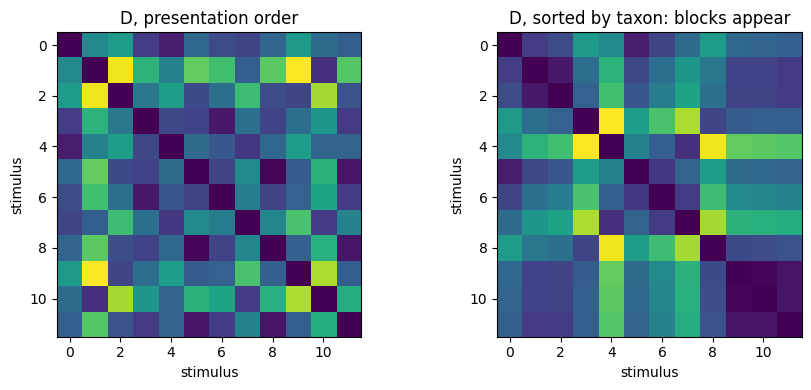

In [24]:
order = np.argsort(taxon)
D_sorted = D[np.ix_(order, order)]

print("D[np.ix_(order, order)].shape:", D_sorted.shape, "  <- the reordered grid")
print("D[order, order].shape:        ", D[order, order].shape,
      "  <- NOT that: paired indexing, 12 diagonal zeros")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(D)
axes[0].set_title("D, presentation order")
axes[1].imshow(D_sorted)
axes[1].set_title("D, sorted by taxon: blocks appear")
for ax in axes:
    ax.set_xlabel("stimulus")
    ax.set_ylabel("stimulus")
plt.tight_layout()
plt.show()

### Exercise 7.1 — the triangle inequality, 5,000 triples at once — RUN WITH ME (in recitation)

A distance is only allowed to be called one if the detour is never shorter:
$d(a, c) \le d(a, b) + d(b, c)$. A1's 1f checks 200,000 random triples;
here are 5,000 on our toy `D`. The sampling lines are given (exactly as A1
gives them); your job is the last two: build the boolean array of violations
and take its mean. The `+ 1e-9` tolerance keeps floating-point rounding from
being counted as a violation.

In [25]:
rng_tri = np.random.default_rng(0)
t = rng_tri.integers(0, n_stimuli, (5000, 3))    # given
a, b, c = t.T                                    # given

viol = D[a, c] > D[a, b] + D[b, c] + 1e-9  # one possible answer — delete and write your own
viol_frac = viol.mean()                    # one possible answer — delete and write your own

In [26]:
# Check cell — run me, do not edit me.
assert getattr(viol, "shape", None) == (5000,), (
    "viol should be one True/False per triple, shape (5000,) — fancy-index D with "
    "the index arrays a, b, c; no loop needed.")
assert np.isscalar(viol_frac) or getattr(viol_frac, "shape", None) == (), (
    "viol_frac should be a single number — the .mean() of the mask.")
assert viol_frac == 0.0, (
    "Euclidean distance NEVER violates the triangle inequality, so the fraction "
    "must be exactly 0 here. A nonzero answer means the comparison is backwards "
    "(the direct path on the left, the detour on the right) or the 1e-9 tolerance "
    "is missing.")
print("Exercise 7.1 passed. Euclidean distance keeps the triangle promise;")
print("whether every distance you build does too is exactly 1f's question.")

Exercise 7.1 passed. Euclidean distance keeps the triangle promise;
whether every distance you build does too is exactly 1f's question.


## 8. AT HOME — a small gallery of silent failures

Five ways numpy goes wrong *without* a useful error at the moment it matters.
Each cell triggers one on purpose; the fix is in the comment. Ten minutes
here will save you an evening in A1.

In [27]:
# 1. A list is not an array: * repeats, it does not multiply.
rates_list = [4.1, 0.5, 7.2]
print("list * 2: ", rates_list * 2)                 # silently: a longer list
print("array * 2:", (np.array(rates_list) * 2))     # what you meant

list * 2:  [4.1, 0.5, 7.2, 4.1, 0.5, 7.2]
array * 2: [ 8.2  1.  14.4]


In [28]:
# 2. Slices are VIEWS: "copying" a row and editing it edits the original.
Rc = R.copy()                 # work on a copy of R so the rest of the notebook survives
row0 = Rc[0]                  # this is NOT a copy
row0[:] = 0.0
print("Rc[0] after editing 'row0':", Rc[0][:4])          # the original changed
print("shared memory?", np.shares_memory(Rc, row0))      # True — same data
# The escape hatch: row0 = Rc[0].copy()

Rc[0] after editing 'row0': [0. 0. 0. 0.]
shared memory? True


In [29]:
# 3. argsort returns POSITIONS, not values.
v = R.mean(axis=1)
idx = np.argsort(v)[:3]
print("positions of the 3 smallest:", idx)
print("the 3 smallest values:      ", v[idx].round(2))   # one more indexing step

positions of the 3 smallest: [ 1 10  7]
the 3 smallest values:       [4.59 5.83 6.51]


In [30]:
# 4. sqrt of a tiny negative is nan — and one nan spreads everywhere.
debris = np.array([-1e-13, 4.0])      # the kind of diagonal section 5 printed
with np.errstate(invalid="ignore"):
    print("sqrt without the clip:", np.sqrt(debris))
print("sqrt with the clip:   ", np.sqrt(np.maximum(debris, 0)))

sqrt without the clip: [nan  2.]
sqrt with the clip:    [0. 2.]


In [31]:
# 5. Floats are not exact — compare with isclose/allclose, never ==.
print("0.1 + 0.2 == 0.3:          ", 0.1 + 0.2 == 0.3)
print("np.isclose(0.1 + 0.2, 0.3):", np.isclose(0.1 + 0.2, 0.3))
# This is why every check in this notebook says allclose, and why A1's 1d
# compares your distances to SciPy's with a tolerance rather than ==.

0.1 + 0.2 == 0.3:           False
np.isclose(0.1 + 0.2, 0.3): True


### Exercise 8.1 — within vs between groups, everything at once — AT HOME

The capstone: broadcasting, fancy indexing, and masks in three lines. Using
`iu` and `D` from section 7, compute the mean distance between stimuli of the
**same** taxon (`mean_within`) and of **different** taxa (`mean_between`).
The pair mask is given: `taxon[iu[0]]` and `taxon[iu[1]]` are the group
labels of each pair's two members, in the fixed pair order.

In [32]:
same_pair = taxon[iu[0]] == taxon[iu[1]]   # given: True where a pair shares a taxon

mean_within = D[iu][same_pair].mean()      # one possible answer — delete and write your own
mean_between = D[iu][~same_pair].mean()    # one possible answer — delete and write your own

In [33]:
# Check cell — run me, do not edit me.
assert np.isscalar(mean_within) or getattr(mean_within, "shape", None) == (), (
    "mean_within should be one number — mask the 66 pair distances D[iu] with "
    "same_pair, then .mean().")
assert abs(mean_within - 10.6) < 0.01, (
    "mean_within is off. D[iu] is the 66 pair distances in fixed order, and "
    "same_pair marks the same-taxon ones — index the first with the second.")
assert abs(mean_between - 21.65) < 0.01, (
    "mean_between is off — the different-taxon pairs are ~same_pair, "
    "the mask flipped.")
assert mean_within < mean_between, (
    "Same-group stimuli should be CLOSER than different-group ones here — if not, "
    "your two masks are swapped.")
print("Exercise 8.1 passed. Within:", round(float(mean_within), 2),
      " between:", round(float(mean_between), 2), "—")
print("same-group stimuli sit closer together. That comparison is the entire")
print("logic of Assignment 1's RDMs, in two numbers.")

Exercise 8.1 passed. Within: 10.6  between: 21.65 —
same-group stimuli sit closer together. That comparison is the entire
logic of Assignment 1's RDMs, in two numbers.


## 9. Where this goes next

You have now run, on a dataset small enough to print, every numpy habit that
Assignment 1 parts 1–2 assume: shapes and `axis=`, broadcasting and its
error, the 1b idiom, boolean masks, and fancy indexing. The
[Recitation 1 deck](https://serre-lab.github.io/CPSY1291-2026/recitations/recitation-01-python-numpy.html)
covers the same ground on slides, and `bootcamp-notes.pdf` in prose. A
one-page **call sheet** with the library signatures for parts 2–3 is coming
to the same Canvas module.

**Next week:** the follow-along for Recitation 2 — curve fitting, R² by
hand, the scikit-learn pattern, PCA, and the code skeletons for the sections
of A1 most likely to stall you.

A reminder, since it bears repeating: this notebook, like the recitations,
is **optional and ungraded**. It exists so that nobody loses a weekend to a
shape error.